In [1]:
import requests
import pandas as pd
from io import StringIO

url = r'https://bit.ly/wine_csv_data'
try:
    r = requests.get(url, timeout=10)
    r.raise_for_status()
    wine = pd.read_csv(StringIO(r.text), low_memory=False)
    if wine is not None:
        print(wine.head())
        print(wine.info())
        print(wine.describe())
        print(wine.columns)
        print(wine['class'].unique())
except Exception as e:
    print(e)

   alcohol  sugar    pH  class
0      9.4    1.9  3.51    0.0
1      9.8    2.6  3.20    0.0
2      9.8    2.3  3.26    0.0
3      9.8    1.9  3.16    0.0
4      9.4    1.9  3.51    0.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   alcohol  6497 non-null   float64
 1   sugar    6497 non-null   float64
 2   pH       6497 non-null   float64
 3   class    6497 non-null   float64
dtypes: float64(4)
memory usage: 203.2 KB
None
           alcohol        sugar           pH        class
count  6497.000000  6497.000000  6497.000000  6497.000000
mean     10.491801     5.443235     3.218501     0.753886
std       1.192712     4.757804     0.160787     0.430779
min       8.000000     0.600000     2.720000     0.000000
25%       9.500000     1.800000     3.110000     1.000000
50%      10.300000     3.000000     3.210000     1.000000
75%      11.300000     8.10

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split

wine_input = wine[['alcohol', 'sugar', 'pH']]
wine_target = wine['class']

train_i, test_i, train_t, test_t = train_test_split(wine_input, wine_target, stratify=wine_target, test_size=0.2, random_state=42)
ss = StandardScaler()
ss.fit(train_i)
train_sc = ss.transform(train_i)
test_sc = ss.transform(test_i)

poly = PolynomialFeatures(degree=4, include_bias=False)
poly.fit(train_sc)
train_scp = poly.transform(train_sc)
test_scp = poly.transform(test_sc)
print(poly.get_feature_names_out(train_i.columns))

lr = LogisticRegression(C=50, max_iter=10000, random_state=42, penalty='l2')
lr.fit(train_scp, train_t)
print(lr.score(train_scp, train_t))
print(lr.score(test_scp, test_t))
print(lr.coef_, lr.intercept_)
print(lr.classes_)
print([(feature, coef) for feature, coef in zip(poly.get_feature_names_out(train_i.columns), lr.coef_[0])])
wine_df = pd.DataFrame(lr.coef_[0], columns=['coef'], index=poly.get_feature_names_out(train_i.columns))
wine_df.sort_values(by = 'coef', ascending=False, inplace=True)
wine_df

['alcohol' 'sugar' 'pH' 'alcohol^2' 'alcohol sugar' 'alcohol pH' 'sugar^2'
 'sugar pH' 'pH^2' 'alcohol^3' 'alcohol^2 sugar' 'alcohol^2 pH'
 'alcohol sugar^2' 'alcohol sugar pH' 'alcohol pH^2' 'sugar^3'
 'sugar^2 pH' 'sugar pH^2' 'pH^3' 'alcohol^4' 'alcohol^3 sugar'
 'alcohol^3 pH' 'alcohol^2 sugar^2' 'alcohol^2 sugar pH' 'alcohol^2 pH^2'
 'alcohol sugar^3' 'alcohol sugar^2 pH' 'alcohol sugar pH^2'
 'alcohol pH^3' 'sugar^4' 'sugar^3 pH' 'sugar^2 pH^2' 'sugar pH^3' 'pH^4']


C:\Users\박중현\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


0.8651144891283433
0.8530769230769231
[[ 4.68906058e-02  8.06065745e+00 -1.73652022e+00  4.16852622e-01
  -3.00312562e+00  4.42350005e-01 -1.75295593e+00 -1.09584985e+00
   2.57445425e-01 -1.59909641e-01  6.08921385e-01  1.65853779e-02
  -5.64689560e-01  1.60810824e-01 -1.94123295e-01 -8.78480851e+00
   1.86723012e-01  3.86764490e-01  1.74181461e-01  3.21537699e-02
  -1.27469989e-01  3.31711018e-02 -2.00787169e-01  2.73785812e-01
   5.61788620e-03  1.91882027e+00 -6.09926926e-01 -1.96820832e-01
  -5.02799094e-02  4.28282790e+00  7.95007492e-02  1.21211515e-01
   9.37005932e-02 -1.02314555e-02]] [2.29632754]
[0. 1.]
[('alcohol', np.float64(0.0468906057835891)), ('sugar', np.float64(8.060657453938598)), ('pH', np.float64(-1.7365202217405706)), ('alcohol^2', np.float64(0.4168526221079866)), ('alcohol sugar', np.float64(-3.00312561620442)), ('alcohol pH', np.float64(0.44235000524719215)), ('sugar^2', np.float64(-1.752955927332107)), ('sugar pH', np.float64(-1.0958498520603102)), ('pH^2', n

,coef
sugar,8.060657
sugar^4,4.282828
alcohol sugar^3,1.918820
alcohol^2 sugar,0.608921
alcohol pH,0.442350
alcohol^2,0.416853
sugar pH^2,0.386764
alcohol^2 sugar pH,0.273786
pH^2,0.257445
sugar^2 pH,0.186723


0.9978833942659227
0.8653846153846154
['alcohol' 'sugar' 'pH']
[0.23393909 0.51450301 0.2515579 ]


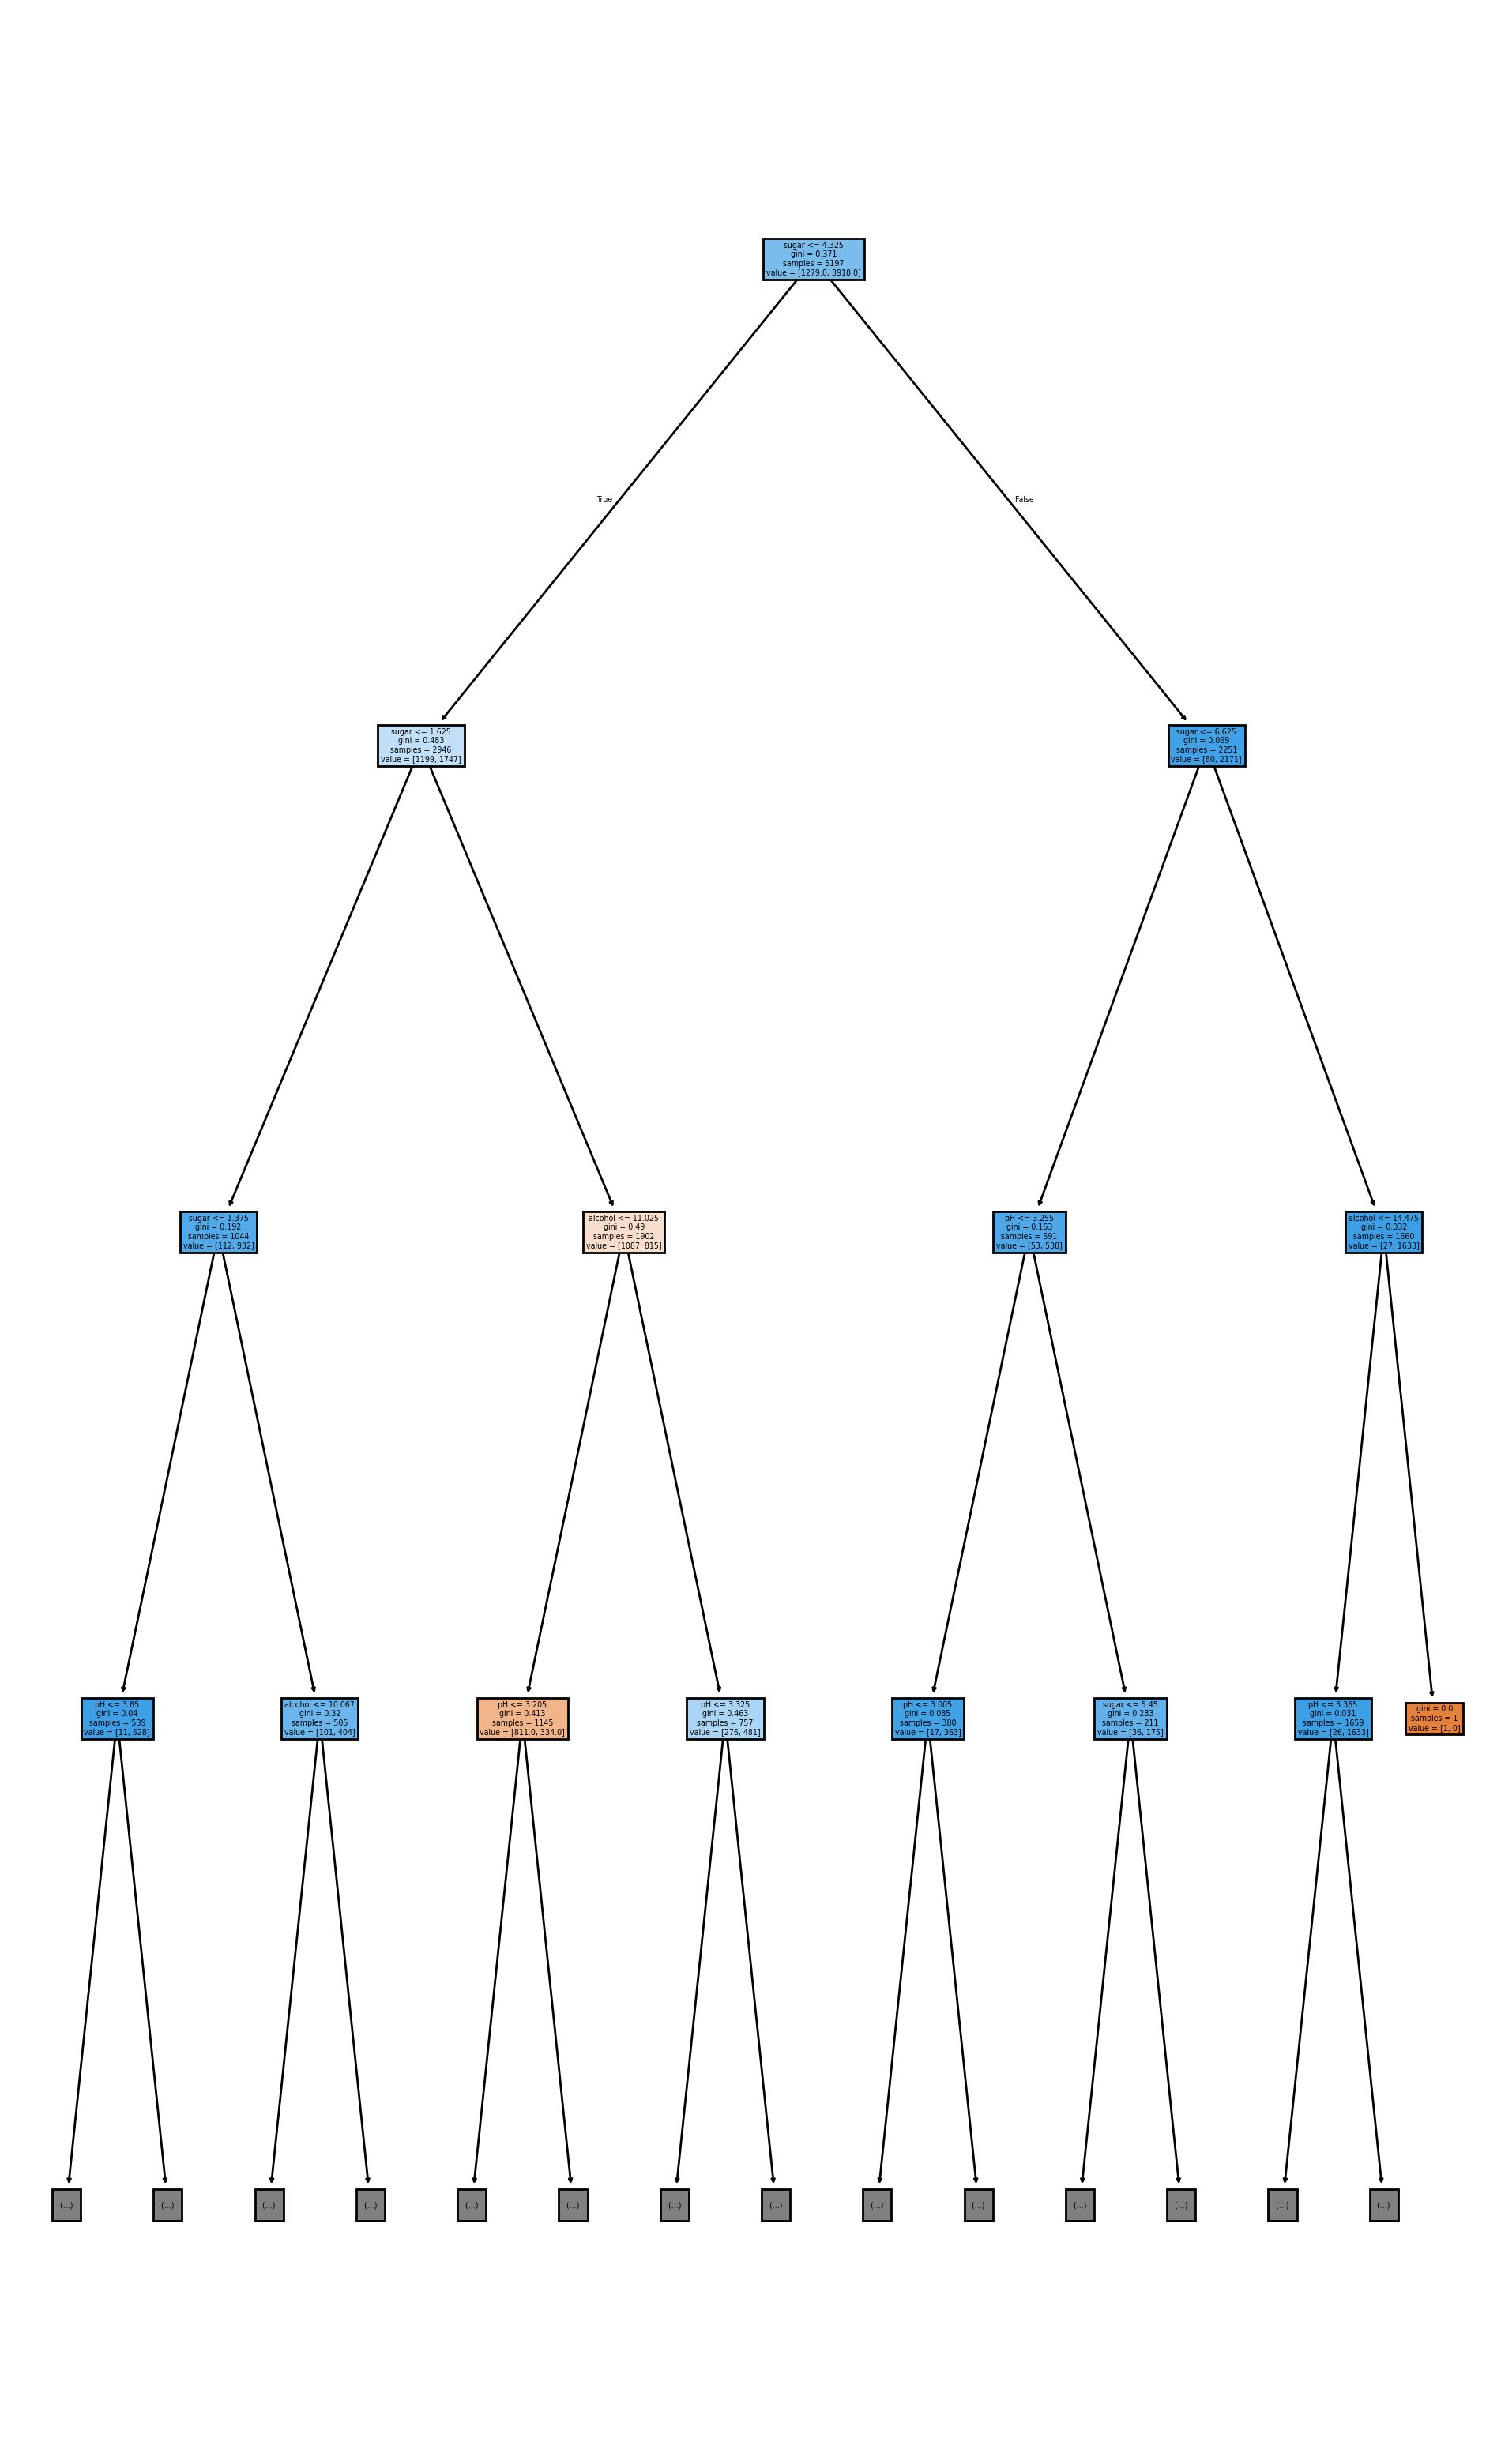

In [3]:
# feature_names = poly.get_feature_names_out(train_i.columns)

# train_scp = pd.DataFrame(train_scp, columns=feature_names, index=train_i.index)
# test_scp = pd.DataFrame(test_scp, columns=feature_names, index=test_i.index)
import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
dt = DecisionTreeClassifier(max_depth=30, random_state=42, criterion='gini')
dt.fit(train_i, train_t)
print(dt.score(train_i, train_t))
print(dt.score(test_i, test_t))
print(dt.feature_names_in_)
print(dt.feature_importances_)

plt.figure(figsize=(12,20), dpi=200)
plot_tree(dt, max_depth=3, feature_names=dt.feature_names_in_, filled=True)
plt.show()




In [ ]:
from sklearn.model_selection import cross_validate, StratifiedKFold
splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_validate(dt, train_i, train_t, cv=splitter, return_train_score=True, return_estimator=True)
print(np.mean(scores['train_score']))
print(np.mean(scores['test_score']))

TypeError: got an unexpected keyword argument 'stratify'

In [ ]:
from sklearn.model_selection import GridSearchCV
params = {'min_impurity_decrease': np.arange(0.0001, 0.001, 0.0001), 
          'max_depth': range(5, 20, 1), 
          'min_samples_split': range(2, 100, 10)}

gs = GridSearchCV(DecisionTreeClassifier(random_state=42), 
                  params, 
                  cv=splitter, 
                  n_jobs=1)

gs.fit(train_i, train_t)
print(gs.best_params_)
print(gs.cv_results_['mean_test_score'])
dt = gs.best_estimator_


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': range(5, 20), 'min_impurity_decrease': array([0.0001... 0.0009]), 'min_samples_split': range(2, 100, 10)}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for

In [20]:
print(gs.best_params_)
print(np.max(gs.cv_results_['mean_test_score']))
dt = gs.best_estimator_
dt.fit(train_i, train_t)
print(dt.score(train_i, train_t))
print(dt.score(test_i, test_t))

{'max_depth': 10, 'min_impurity_decrease': np.float64(0.0004), 'min_samples_split': 2}
0.8689623898719182
0.8924379449682509
0.86


In [28]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

params = {'min_impurity_decrease': uniform(0.0001, 0.01),
          'max_depth': randint(3, 50),
          'min_samples_split': randint(2, 25),
          'min_samples_leaf': randint(1, 25)}

rs = RandomizedSearchCV(DecisionTreeClassifier(random_state=42),
                        params,
                        n_iter=100,
                        n_jobs=1,
                        cv = splitter)
rs.fit(train_i, train_t)
print(rs.best_params_)
print(np.max(rs.cv_results_['mean_test_score']))
dt = rs.best_estimator_
print(dt.score(train_i, train_t))
print(dt.score(test_i, test_t))


{'max_depth': 22, 'min_impurity_decrease': np.float64(0.0002837513688588055), 'min_samples_leaf': 23, 'min_samples_split': 20}
0.8687700821796106
0.8880123147969983
0.8576923076923076
